<font color=#009afa size=50>DAT-6002 - Fundamentals of Artificial Intelligence</font><br>
<font size=50>WRIT1 Part 2 - Neural Networks</font><br>
<font size=20 color=#00c382>2 - From Scratch MLP - Bank Data</font><br>

|**Assessment Code:** |WRIT1|
|---|---|
|**Author:**|Tom Rowan|
|**Course:**|DAT6002_S2_25|
|**Course Tutor:**|Imtiaz Hussain Khan, PhD|


---

# Initialise Notebook

In [ ]:
# Install Requirements Using Pip
%pip install -r requirements.txt

### Import Python Libraries

In [288]:
# Standard Libraries
import sys
import json
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
#from matplotlib import colormaps
#import matplotlib.colors as mcolors
#from matplotlib.pyplot import figure
#import matplotlib.ticker as mticker
#import matplotlib.animation as animation
%matplotlib inline

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Create a Timestamp

In [289]:
# Generate Timestamp
today = pd.Timestamp(datetime.today())
now_date_timestamp = str(today.strftime("%Y%m%d"))
now_datetime_timestamp = str(today.strftime("%Y%m%d-%H%M"))

### Functions for Pretty Output

print_output - Print coloured Output

In [290]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow', newline=True):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
        
    # Newline - defaul to a newline
    nl=None if newline else ' '
    
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}', end=nl)

### Check for Internet Access

In [291]:
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.github.com',
                  'https://datascience.daemonchild.com']

Set this to False if you have a local dataset

In [292]:
internet_required = False

In [293]:
# Function to Safely Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online

# Perform the checks
if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    online = False


# Stop running if Internet is required
if online == False & internet_required == True:
    sys.exit('Stopping notebook run here.')    


[INTERNET] Internet Connectivity Detected. Using Internet resources.


### Define Colour Palette

In [294]:
COLOUR_TEAL = '#31688E'
COLOUR_ORANGE = '#CF4446'
COLOUR_GREEN = '#35B779'
COLOUR_YELLOW = '#FDE725'


palette=[COLOUR_TEAL, COLOUR_ORANGE, COLOUR_GREEN, COLOUR_YELLOW]

# Set global parameters
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[COLOUR_TEAL, COLOUR_ORANGE])
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['grid.alpha'] = 0.3

---
# Load the Dataset

In [ ]:
if online:
    # Fetch the dataset from the Internet
    df = pd.read_csv('https://datascience.daemonchild.com/year3/dat6002/bank_full_scaled_latest.csv', delimiter=',')
else:
    # Load the dataset from local file
    df = pd.read_csv('datasets/bank_full_scaled_latest.csv', delimiter=',')

In [296]:
df.shape

(45211, 29)

In [297]:
df.sample(5)

,age,balance,housing,loan,campaign,previous,y,pdays_binned,month_numeric,education_numeric,...,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown
2632,1.041921,-0.438880,1.0,0.0,-0.569351,-0.251940,0.0,0.0,0.363636,0.333333,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2850,0.759399,-0.194852,1.0,0.0,-0.569351,-0.251940,0.0,0.0,0.363636,0.333333,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
21253,1.606965,-0.435267,0.0,0.0,2.658552,-0.251940,0.0,0.0,0.636364,0.333333,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
40754,-0.276515,-0.431983,1.0,0.0,-0.569351,1.918749,0.0,0.5,0.636364,0.333333,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
24415,0.382703,1.005910,0.0,0.0,-0.569351,0.616335,0.0,0.5,0.909091,0.333333,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


### Pre-MLP Processing

Now it is necessary to split the input dataset into two parts - testing and training data.<br>
I am using an 80/20 split with 80% of the data going towards training.<br>
Validation data will be further split from this chunk within the MLP class below.

Initially, I was using the following simple code to split the data:

```
# Split data frame into 80/20
df_train = df.sample(frac = 0.8, random_state = 67)
# Creating dataframe with rest of the 20% values
df_test = df.drop(df_train.index)
```

However, this does not guarantee that the data includes exactly the same proportions of yes/no results as shown here:<br>

```
# Print the percentage distribution of the target variable 'y'
print ((df_train['y'].value_counts(normalize=True).round(4) * 100))
# Print the percentage distribution of the target variable 'y'
print ((df_test['y'].value_counts(normalize=True).round(4) * 100))
```

Results:

```
y
0.0    88.42
1.0    11.58
Name: proportion, dtype: float64
y
0.0    87.83
1.0    12.17
Name: proportion, dtype: float64
```

Therefore, I wrote the following function to split the data so that each chunk contains the same proportions.

```
def split_test_train (frac=0.8, random_state=67):

    # Separate yes and no into two dataframes
    df_yes = df[df['y'] == 1]
    df_no = df[df['y'] == 0]

    # Sample 80% from each to maintain the 11.7% ratio
    df_train_yes = df_yes.sample(frac=frac, random_state=random_state)
    df_train_no = df_no.sample(frac=frac, random_state=random_state)

    # Combine and Shuffle to prevent date order being learned by the MLP
    df_train = pd.concat([df_train_yes, df_train_no]).sample(frac=1, random_state=random_state)
    df_test = df.drop(df_train.index).sample(frac=1, random_state=random_state)

    return df_train, df_test

# Used like this:
df_train, df_test = split_test_train()
```

This is all implemented inside the MLP class so that the code can be used to split off test and train, as well as being used to split validation from the training data.

In [298]:
df.columns

Index(['age', 'balance', 'housing', 'loan', 'campaign', 'previous', 'y',
       'pdays_binned', 'month_numeric', 'education_numeric',
       'poutcome_numeric', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown'],
      dtype='str')

### Function to draw a generic neural network diagram

This function was created using Google Gemini for speed as it is only really used to illustrate the network for the report.<br>
It is called from within the MLP class if debug is turned on to draw out the network, with lines showing connections between the neurons.

In [299]:

def draw_neural_network(ax, left, right, bottom, top, layer_sizes):

    v_spacing = (top - bottom)/float(max(layer_sizes))
    h_spacing = (right - left)/float(len(layer_sizes) - 1)
    
    # Draw nodes
    for n, layer_size in enumerate(layer_sizes):
        layer_top = v_spacing*(layer_size - 1)/2. + (top + bottom)/2.
        for m in range(layer_size):
            circle = plt.Circle((n*h_spacing + left, layer_top - m*v_spacing), 
                                v_spacing/4., color='skyblue', ec='k', zorder=4)
            ax.add_artist(circle)
            
            # Add labels for layers
            if m == 0:
                if n == 0: ax.text(n*h_spacing + left, top + 0.1, f'Input Layer (N = {layer_size})', ha='center')
                if n == 1: ax.text(n*h_spacing + left, top + 0.1, f'Hidden Layer ({layer_size})', ha='center')
                if n == 2: ax.text(n*h_spacing + left, top + 0.1, f'Output Layer (M = {layer_size})', ha='center')

    # Draw edges (weights)
    for n, (layer_size_a, layer_size_b) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:])):
        layer_top_a = v_spacing*(layer_size_a - 1)/2. + (top + bottom)/2.
        layer_top_b = v_spacing*(layer_size_b - 1)/2. + (top + bottom)/2.
        for m in range(layer_size_a):
            for o in range(layer_size_b):
                line = plt.Line2D([n*h_spacing + left, (n + 1)*h_spacing + left],
                                  [layer_top_a - m*v_spacing, layer_top_b - o*v_spacing], 
                                  c='gray', lw=0.5, alpha=0.3)
                ax.add_artist(line)



# Neural Network

"Construct a three-layer feedforward neural network consisting of N input neurons, 10 hidden neurons, and M output neuron(s)."

## MLP Class 

### Public Functions

**Constructor**<br>
Initializes the network architecture by setting the number of neurons in each layer. It also splits the dataset into training, test and validation sets. Finally, it generates the initial weight matrices and bias vectors using random distributions.

**set_model_parameters**<br>
Allows updating of model parameters (e.g. learning rate, output threshold) without needing to retrain the model from scratch.

**train_network**<br>
The main training loop that iterates through the dataset for a specified number of epochs. It coordinates the forward pass, error calculation, and backpropagation to update the model parameters. If debug is set to true, the loss will be output to screen every 100 epochs.

**evaluate**<br>
Calculates the final performance metrics of the model on a test dataset. Returns Accuracy based on a supplied dataset.

**plot_error**<br>
Plots the error values recorded during training.

**plot_confusion_matrix**<br>
Plots a confusion matrix graphically.

**print_confusion_matrix**<br>
Prints a text based confusion matrix.

**save_weights**<br>
Saves the model weights and biases to a json file for later use.

**load_weights**<br>
Loads the model weights and biases fron a json file.

**get_report**<br>
Returns the Accuracy, Recall, Precision and F1-Score for the trained model using test data.

### Private Functions

**_split_stratified**<br>
Splits a dataset into two sections using the suppled fraction maintaining the proportion of yes/nbo results in the result.<br> 
Also shuffles the result to avoid date order being a factor.

**_x_and_y_split**<br>
Splits the dataset into a source and target pair. In the assignment, it splits 'y' from the rest of the data.

**_check_proportion**<br>
Checks the data to ensure that the proportions have actually been maintained by_split_stratified.

**_relu**<br>
**_relu_derivative**<br>
Activation function and derivative for back propogation.

**_sigmoid**<br>
**_sigmoid_derivative**<br>
Activation function and derivative for back propogation.

**_feed_forward**<br>
Performs the forward pass through the network applying the weights and activation functions.<br>
Can use either relu or sigmoid activation function for hidden layer. Output layer always uses sigmoid.

**_back_propogation_output**<br>
Calculate the error/loss for the output layer. Can use either bce or mse loss calculations functions.

**_back_propogation_hidden**<br>
Calcumate the error/loss for the hidden layer. Can use either relu or sigmoid activation function.

**_weight_bias_update**<br>
Perform the update of weights and biases based on calculated losses.

**_get_predictions**<br>
Run the feed forward process and return the predicted classes (0 or 1) based on the output threshold

**_calculate_accuracy**<br>
Calculate accuracy by comparing predicted classes to true labels, returns the mean of the result as a percentage.

**_get_confusion_matrix**<br>
Performs the maths to generate a confusion matrix.






In [300]:
class MLP_From_Scratch:

    # Constructor
    def __init__(self, dataset, **kwargs):

        # Handle Arguments

        self.dataset = dataset

        _random_seed = kwargs.get('random_seed', 67)
        self.debug = kwargs.get('debug', False)

        _test_train_split = kwargs.get('test_train_split', 0.8)    # Default to 80% of the supplied data
        _validation_split = kwargs.get('validation_split', 0.2)    # Default to 20% of the training data

        # Split off training, test and validationdatasets

        df_train, df_test = self._split_stratified (data_set=self.dataset, fraction=_test_train_split, random_state=_random_seed)
        df_train, df_val = self._split_stratified (data_set=df_train, fraction=1-_validation_split, random_state=_random_seed)

        # Split inot X and y for each dataset
        X_train, y_train = self._x_and_y_split(df_train)
        X_test, y_test = self._x_and_y_split(df_test)
        val_X, val_y = self._x_and_y_split(df_val)

        # Convert provided data to numpy arrays
        self.X_np_train = X_train.to_numpy()
        self.y_np_train = y_train.to_numpy().reshape(-1,1)

        self.X_np_val = val_X.to_numpy()
        self.y_np_val = val_y.to_numpy().reshape(-1,1)

        self.X_np_test = X_test.to_numpy()
        self.y_np_test = y_test.to_numpy().reshape(-1,1)

        # Additional Model Parameters
        _act_func = kwargs.get('act_func', 'relu')                      # Hidden layer only, defaults to relu
        _no_hidden_neurons = kwargs.get('no_hidden_neurons', 10)        # Defaults to 10 hidden neurons, per assessment specification
        _no_output_neurons = kwargs.get('no_output_neurons', 1)
        self.output_threshold = kwargs.get('output_threshold', 0.5)
        self.loss_type = kwargs.get('loss_type', 'bce')                 # Loss type for backpropagation, default to Binary Cross-Entropy (BCE)

        # Define Model Parameters
        self.no_input_neurons  = self.X_np_train.shape[1]               # Set dynamically based on the input dataset
        self.no_hidden_neurons = _no_hidden_neurons          
        self.no_output_neurons = _no_output_neurons
        self.learning_rate = 0.03          
        self.act_func = _act_func

        # Initialize Weights with small random numbers
        # 
        #   input_neurons --> weights_0 --> hidden_neurons --> weights_1 --> output_neurons
        #                                   biases_1                         biases_2
        #
        np.random.seed(_random_seed)

        self.weights_0 = np.random.randn(self.no_input_neurons, self.no_hidden_neurons) 
        self.weights_1 = np.random.randn(self.no_hidden_neurons, self.no_output_neurons)

        self.biases_1 = np.zeros((1, self.no_hidden_neurons))
        self.biases_2 = np.zeros((1, self.no_output_neurons))


        if self.debug:
            print_output("No Input Layer Neurons", self.no_input_neurons)
            print_output("No Input to Hidden Weights", self.weights_0.size, colour='blue')

            print_output("No Hidden Layer Neurons", self.no_hidden_neurons)
            print_output("No Hidden Layer Biases", self.biases_1.size, colour='blue')
            print_output("Hidden Layer Activation", self.act_func, colour='green')

            print_output("No Hidden to Output Weights", self.weights_1.size, colour='blue')
        
            print_output("No Output Layer Neurons", self.no_output_neurons)
            print_output("No Output Layer Biases", self.biases_2.size, colour='blue')

            print ("")

            print_output("Training 'Yes' Ratio", f"{np.mean(self.y_np_train):.4f}", colour='green')
            print_output("Validation 'Yes' Ratio", f"{np.mean(self.y_np_val):.4f}", colour='green')
            print_output("Test 'Yes' Ratio", f"{np.mean(self.y_np_test):.4f}", colour='green')

            print ("")

            # Setup plot
            fig = plt.figure(figsize=(10, 8))
            ax = fig.gca()
            ax.axis('off')

            draw_neural_network(ax, .1, .9, .1, .9, [self.no_input_neurons, self.no_hidden_neurons, self.no_output_neurons])
            plt.savefig(f'graphs/2-mlp_from_scratch/mlp_architecture_{now_date_timestamp}.png', bbox_inches='tight', dpi=300)
            plt.show()

    #
    # ***** Data Handling Functions
    # 
    
    def _split_stratified (self, data_set, fraction=0.8, random_state=67):

        # Separate yes and no into two dataframes
        df_yes = data_set[data_set['y'] == 1]
        df_no = data_set[data_set['y'] == 0]

        # Sample 80% from each to maintain the source to target ratio
        df_train_yes = df_yes.sample(frac=fraction, random_state=random_state)
        df_train_no = df_no.sample(frac=fraction, random_state=random_state)

        # Combine and Shuffle to prevent date order being learned by the MLP
        df_train = pd.concat([df_train_yes, df_train_no]).sample(frac=1, random_state=random_state)
        df_test = data_set.drop(df_train.index).sample(frac=1, random_state=random_state)

        return df_train, df_test
    
    def _x_and_y_split (self, df):
        # Split datasets into X (features) and y (labels)
        df_X = df.drop(columns='y')
        df_y = df['y']
        return df_X, df_y
    
    def _check_proportion (df, label_col='y'):
        # Print the percentage distribution of the target variable
        distribution = df[label_col].value_counts(normalize=True).round(4) * 100
        print (distribution)
        return distribution

    #
    # ***** Activation Functions 
    #

    def _relu(self, x):
        return np.maximum(0, x)

    def _relu_derivative(self, x):
        return (x > 0).astype(float)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _sigmoid_derivative(self, x):
        return x * (1 - x)

    
    #
    # ***** MLP Process Functions 
    #

    def _feed_forward(self, X):

        # Dot product of inputs and weights, plus bias, to get the sum for the hidden layer
        sum_synapse_0 = np.dot(X, self.weights_0) + self.biases_1

        # Allows for choice of activation function for hidden layer (default is ReLU)
        if self.act_func == 'sigmoid':
            hidden_layer = self._sigmoid(sum_synapse_0)
        else:
            hidden_layer = self._relu(sum_synapse_0)
        
        
        # Dot product of inputs and weights, plus bias, to get the sum for the output layer
        sum_synapse_1 = np.dot(hidden_layer, self.weights_1) + self.biases_2

        # Always use sigmoid on the output layer
        output_layer = self._sigmoid(sum_synapse_1)
        
        # Return everything
        return X, hidden_layer, output_layer
    
    
    def _back_propagation_output(self, output_layer):

        error_output_layer = self.y_np_train - output_layer
        
        # This is used for monitoring the error during training, but is not used in the backpropagation calculations
        average_error = np.mean(np.abs(error_output_layer))
        
        # Choose Loss Type and calculate delta_output accordingly
        if self.loss_type == 'bce':
            delta_output = error_output_layer
        elif self.loss_type == 'mse':
            derivative_output = self._sigmoid_derivative(output_layer)
            delta_output = error_output_layer * derivative_output

        return delta_output, average_error
    
    
    def _back_propagation_hidden(self, delta_output, hidden_layer):
    
        # Transpose the numpy array
        weights_1T = self.weights_1.T
        
        delta_output_weight = delta_output.dot(weights_1T)

        if self.act_func == 'sigmoid':
            delta_hidden_layer = delta_output_weight * self._sigmoid_derivative(hidden_layer)
        else:
            delta_hidden_layer = delta_output_weight * self._relu_derivative(hidden_layer)
        
        hidden_layerT = hidden_layer.T
        input_x_delta1 = hidden_layerT.dot(delta_output)

        return delta_hidden_layer, input_x_delta1
    

    def _weight_bias_update(self, input_layer, input_x_delta1, delta_hidden_layer, delta_output):

        m = input_layer.shape[0]                                                          # Batch size
        
        # Compute the average gradient across batches and update weights for hidden to output layer
        self.weights_1 = self.weights_1 + (input_x_delta1 / m * self.learning_rate)       
        
        input_layerT = input_layer.T
        input_x_delta0 = input_layerT.dot(delta_hidden_layer)
        self.weights_0 = self.weights_0 + (input_x_delta0 / m * self.learning_rate)                                                            

        self.biases_1 = self.biases_1 + np.sum(delta_hidden_layer, axis=0, keepdims=True) / m * self.learning_rate
        self.biases_2 = self.biases_2 + np.sum(delta_output, axis=0, keepdims=True) / m * self.learning_rate 

    # Run the feed forward process and return the predicted classes (0 or 1) based on the output threshold
    def _get_predictions(self, X):
        _, _, output = self._feed_forward(X)
        return (output > self.output_threshold).astype(int)


    # Calculate accuracy by comparing predicted classes to true labels
    def _calculate_accuracy(self, X, y):
        y_pred = self._get_predictions(X)
        return np.mean(y_pred == y) * 100
    
    # Calculate the confusion matrix components and overall accuracy for a supplied dataset
    def _get_confusion_matrix(self, X_data=None, y_data=None):
            
        # Default to the test set if no specific data is provided
        if X_data is None:
            X_data = self.X_np_test
            y_data = self.y_np_test

        y_pred = self._get_predictions(X_data)
        
        # Flatten the arrays to ensure they are 1D to compare
        y_true = y_data.flatten()
        y_pred = y_pred.flatten()
        
        # Calculate True Positives, True Negatives, False Positives, and False Negatives
        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        accuracy = (tp + tn) / len(y_true)
        
        return np.array([[tn, fp], [fn, tp]]), accuracy

    #
    # ***** Public Functions 
    #

    # Allows updating of model parameters (e.g. learning rate, output threshold) without needing to retrain the model from scratch
    def set_model_parameters(self, **kwargs):
        self.learning_rate = kwargs.get('learning_rate', self.learning_rate)
        self.output_threshold = kwargs.get('output_threshold', self.output_threshold)

    def train_network(self, epochs, **kwargs):

        # Set up parameters
        self.learning_rate = kwargs.get('learning_rate', self.learning_rate)
        self.loss_type = kwargs.get('loss_type', 'bce')

        self.train_error_history = []
        self.valid_error_history = [] 

        epsilon = 1e-15  # Small value to prevent log(0) in loss calculation

        for epoch in range(epochs):

            # Forward
            input_layer, hidden_layer, output_layer = self._feed_forward(self.X_np_train)

            # --- Calculate Binary Cross-Entropy Loss ---
            output_layer_clipped = np.clip(output_layer, epsilon, 1 - epsilon)
            loss = -np.mean(self.y_np_train * np.log(output_layer_clipped) + (1 - self.y_np_train) * np.log(1 - output_layer_clipped))
        
            # --- Monitor Weights ---
            # This tells you if your weights are becoming massive (Exploding Gradient)
            w_hidden_mean = np.mean(np.abs(self.weights_0))
            w_out_mean = np.mean(np.abs(self.weights_1))
                
            # Back prop (Output)
            delta_output, train_error = self._back_propagation_output(output_layer)
            
            # Back prop (Hidden)
            delta_hidden_layer, input_x_delta1 = self._back_propagation_hidden(delta_output, hidden_layer)
            
            # Update Weights
            self._weight_bias_update(input_layer, input_x_delta1, delta_hidden_layer, delta_output)

            if epoch % 100 == 0:
                #  Use the feed_forward method but with validation data
                _, _, test_output = self._feed_forward(self.X_np_val)
                
                # Calculate validation error (Mean Absolute Error)
                valid_error = np.mean(np.abs(self.y_np_val - test_output))

                # Calculate BCE for validation set
                test_output_clipped = np.clip(test_output, epsilon, 1 - epsilon)
                val_loss = -np.mean(self.y_np_val * np.log(test_output_clipped) + (1 - self.y_np_val) * np.log(1 - test_output_clipped))
                
                # Store calculated losses for graphing later
                self.train_error_history.append(loss) 
                self.valid_error_history.append(val_loss)

                if self.debug:
                    print_output(" +- Epoch", f"{epoch} - ", newline=False, colour='cyan')
                    print_output("Training Err", f"{train_error:.4f} ", newline=False, colour='red')
                    print_output("Validation Err", f"{valid_error:.4f}", newline=False, colour='red')
                    print_output("Loss", f"{loss:.4f}", newline=False, colour='green')
                    print_output("Hidden Weights Mean", f"{w_hidden_mean:.4f}", newline=False, colour='yellow')
                    print_output("Output Weights Mean", f"{w_out_mean:.4f}", newline=True, colour='yellow')
                else:
                    print(".", end='')

                    
    # Evaluate the model on the provided dataset and return accuracy
    # Allows specifying a custom output threshold for prediction
    # Allows proving a custom dataset instead of the default test set
    def evaluate(self, X_data=None, y_data=None):
            
        # Default to the test set if no specific data is provided
        if X_data is None:
            X_data = self.X_np_test
            y_data = self.y_np_test
        
        self.accuracy = self._calculate_accuracy(X_data, y_data)
        return self.accuracy 
    

    def plot_error(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.train_error_history, label='Training Loss', color=palette[0])
        plt.plot(self.valid_error_history, label='Validation Loss', linestyle='--', color=palette[2])
        plt.xlabel('Epochs (x100)')
        plt.ylabel('Binary Cross-Entropy Loss')
        plt.title('Training vs Validation Loss')
        plt.legend()
        plt.savefig(f'graphs/2-mlp_from_scratch/mlp_training_validation_loss_{now_date_timestamp}.png')
        plt.show()


    def plot_confusion_matrix(self):

        matrix, accuracy = self._get_confusion_matrix()
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(matrix, cmap='Blues')

        # Add colorbar
        plt.colorbar(im)

        # Set labels
        classes = ['No (0)', 'Yes (1)']
        ax.set_xticks(np.arange(len(classes)))
        ax.set_yticks(np.arange(len(classes)))
        ax.set_xticklabels(classes)
        ax.set_yticklabels(classes)

        # Rotate the tick labels and set their alignment.
        plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

        # Loop over data dimensions and create text annotations.
        for i in range(2):
            for j in range(2):
                text = ax.text(j, i, matrix[i, j],
                            ha="center", va="center", color="black", fontsize=14)

        ax.set_title("Confusion Matrix Heatmap")
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        plt.tight_layout()
        plt.savefig(f'graphs/2-mlp_from_scratch/mlp_confusion_matrix_{now_date_timestamp}_threshold_{self.output_threshold}.png')
        plt.show()


    # Text Representation
    def print_confusion_matrix(self):
        matrix, self.accuracy = self._get_confusion_matrix() 
        print(f"{'':>15} | {'Predicted No':>12} | {'Predicted Yes':>12} |")
        print("-" * 48)
        print(f"{'Actual No':>15} | {matrix[0][0]:>12} | {matrix[0][1]:>12} |")
        print(f"{'Actual Yes':>15} | {matrix[1][0]:>12} | {matrix[1][1]:>12} |")
        print("-" * 48)
        print (f"Accuracy: {self.accuracy:.2f}%")


    # Export the model weights and biases to a JSON file
    def save_weights(self, filename):
        weights_data = {
            'weights_0': self.weights_0.tolist(),
            'weights_1': self.weights_1.tolist(),
            'biases_1': self.biases_1.tolist(),
            'biases_2': self.biases_2.tolist()
        }
        with open(filename, 'w') as f:
            json.dump(weights_data, f, indent=4)

    # Load the model weights and biases from a JSON file
    def load_weights(self, filename):
        with open(filename, 'r') as f:
            weights_data = json.load(f)
            self.weights_0 = np.array(weights_data['weights_0'])
            self.weights_1 = np.array(weights_data['weights_1'])
            self.biases_1 = np.array(weights_data['biases_1'])
            self.biases_2 = np.array(weights_data['biases_2'])

    def get_report(self, X_data=None, y_data=None):
            
        # Default to the test set if no specific data is provided
        if X_data is None:
            X_data = self.X_np_test
            y_data = self.y_np_test

        # Get the confusion matrix components
        matrix, accuracy = self._get_confusion_matrix(X_data, y_data)
        tn, fp = matrix[0]
        fn, tp = matrix[1]

        # Calculate metrics (with safety for division by zero)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        print(f"--- Performance Report (Threshold: {self.output_threshold}) ---")
        print(f" +- Accuracy:  {accuracy:.4f}")
        print(f" +- Precision: {precision:.4f}")
        print(f" +- Recall:    {recall:.4f} ")
        print(f" +- F1-Score:  {f1:.4f} ")
        
        return {"acc": accuracy, "prec": precision, "rec": recall, "f1": f1}
        

This is a binary classification problem, which implies 1 output neuron

No Input Layer Neurons: 28
No Input to Hidden Weights: 280
No Hidden Layer Neurons: 10
No Hidden Layer Biases: 10
Hidden Layer Activation: relu
No Hidden to Output Weights: 10
No Output Layer Neurons: 1
No Output Layer Biases: 1

Training 'Yes' Ratio: 0.1170
Validation 'Yes' Ratio: 0.1169
Test 'Yes' Ratio: 0.1170



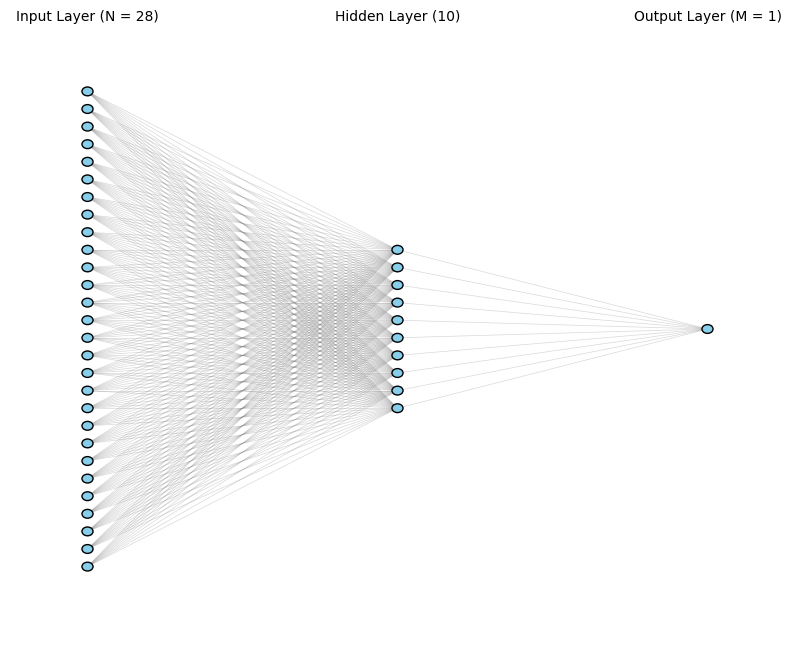

 +- Epoch: 0 -  Training Err: 0.6412  Validation Err: 0.5995 Loss: 1.8728 Hidden Weights Mean: 0.7720 Output Weights Mean: 0.6623
 +- Epoch: 100 -  Training Err: 0.2285  Validation Err: 0.2281 Loss: 0.4622 Hidden Weights Mean: 0.7659 Output Weights Mean: 0.5878
 +- Epoch: 200 -  Training Err: 0.2202  Validation Err: 0.2194 Loss: 0.4123 Hidden Weights Mean: 0.7636 Output Weights Mean: 0.5521
 +- Epoch: 300 -  Training Err: 0.2159  Validation Err: 0.2149 Loss: 0.3938 Hidden Weights Mean: 0.7619 Output Weights Mean: 0.5251
 +- Epoch: 400 -  Training Err: 0.2133  Validation Err: 0.2123 Loss: 0.3829 Hidden Weights Mean: 0.7607 Output Weights Mean: 0.5017
 +- Epoch: 500 -  Training Err: 0.2115  Validation Err: 0.2106 Loss: 0.3753 Hidden Weights Mean: 0.7597 Output Weights Mean: 0.4808
 +- Epoch: 600 -  Training Err: 0.2102  Validation Err: 0.2095 Loss: 0.3694 Hidden Weights Mean: 0.7590 Output Weights Mean: 0.4623
 +- Epoch: 700 -  Training Err: 0.2091  Validation Err: 0.2085 Loss: 0.3647 Hi

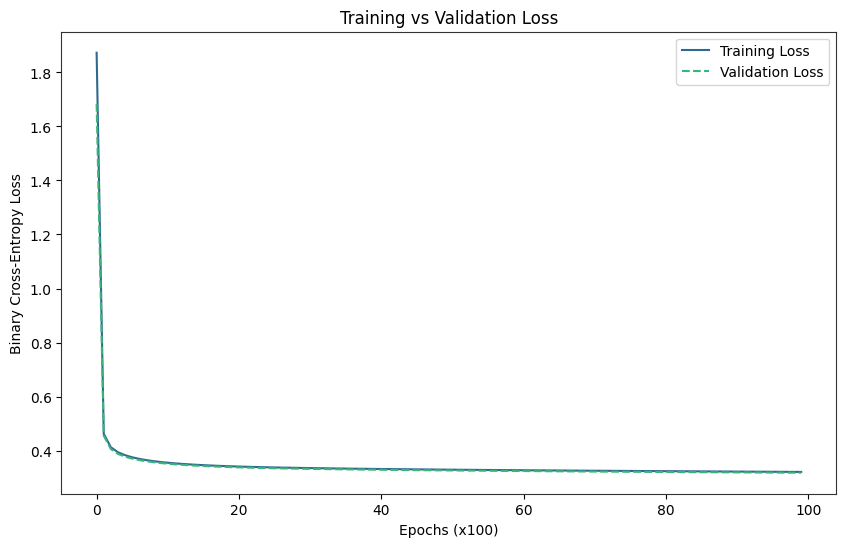

In [301]:
df.reset_index(drop=True, inplace=True)
mlp = MLP_From_Scratch(dataset = df, debug=True, learning_rate=0.005, output_threshold=0.5 )
mlp.train_network(epochs=10000)
mlp.plot_error()


Save out the weights for later use

In [302]:
mlp.save_weights('mlp_weights.json')

### Model Evaluation Metrics

| Metric | Mathematical Formula | Description | What it tells the Bank |
| :--- | :---: | :--- | :--- |
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | The proportion of total predictions that were correct. | Overall success rate  |
| **Precision** | $\frac{TP}{TP + FP}$ | The proportion of positive identifications that were actually correct. | "When we call someone a potential customer, how often are we right?" |
| **Recall** | $\frac{TP}{TP + FN}$ | The proportion of actual positives that were identified correctly. | Out of everyone who would have said 'Yes', how many did we actually find? |
| **F1-Score** | $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$ | The mean of Precision and Recall. | The "balanced" score that punishes models for ignoring the minority class. |

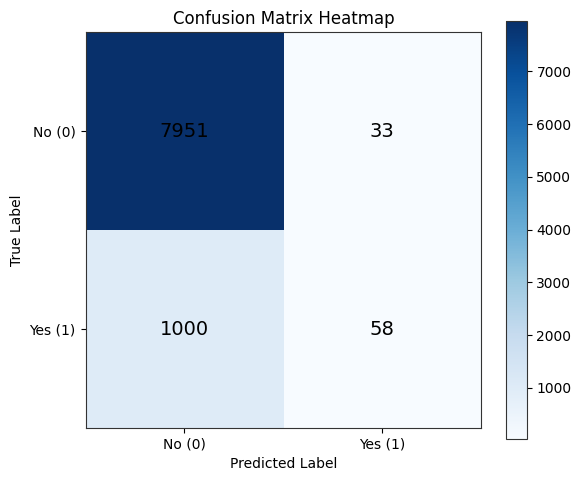

In [303]:
mlp.set_model_parameters(output_threshold=0.50)
mlp.plot_confusion_matrix()

In [304]:
mlp.set_model_parameters(output_threshold=0.50)
mlp.get_report()

--- Performance Report (Threshold: 0.5) ---
 +- Accuracy:  0.8858
 +- Precision: 0.6374
 +- Recall:    0.0548 
 +- F1-Score:  0.1010 


{'acc': np.float64(0.8857553638575536),
 'prec': np.float64(0.6373626373626373),
 'rec': np.float64(0.054820415879017016),
 'f1': np.float64(0.1009573542210618)}

Exploring different output thresholds as a 'solution' to model bias.

In [305]:
results_list = []

for threshold in np.arange(0, 1, 0.1):
    threshold=threshold.round(1)
    print_output("\nTesting with output bias threshold", threshold, colour='cyan')
    
    # Dynamically update the model's output threshold and re-evaluate without needing to retrain
    mlp.set_model_parameters(output_threshold=threshold)
    report = mlp.get_report()
    
    results_list.append({
        'Threshold': threshold,
        'Accuracy': report['acc'],
        'Precision': report['prec'],
        'Recall': report['rec'],
        'F1-Score': report['f1']
    })

    mlp.print_confusion_matrix()

# Convert to DataFrame for plotting
df_metrics = pd.DataFrame(results_list)


Testing with output bias threshold: 0.0
--- Performance Report (Threshold: 0.0) ---
 +- Accuracy:  0.1170
 +- Precision: 0.1170
 +- Recall:    1.0000 
 +- F1-Score:  0.2095 
                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |            0 |         7984 |
     Actual Yes |            0 |         1058 |
------------------------------------------------
Accuracy: 0.12%

Testing with output bias threshold: 0.1
--- Performance Report (Threshold: 0.1) ---
 +- Accuracy:  0.6042
 +- Precision: 0.1884
 +- Recall:    0.7202 
 +- F1-Score:  0.2986 
                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |         4701 |         3283 |
     Actual Yes |          296 |          762 |
------------------------------------------------
Accuracy: 0.60%

Testing with output bias threshold: 0.2
--- Performance Report (Threshold: 0.2) ---
 +- Accuracy:  0.8237
 +- Precision: 0.3134
 +-

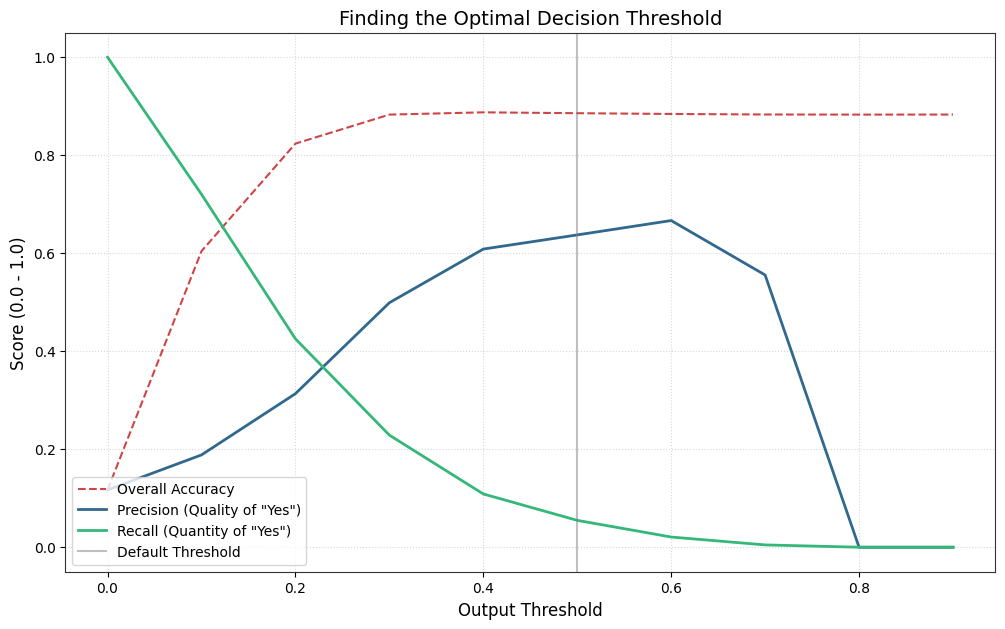

In [306]:
plt.figure(figsize=(12, 7))

# Plot the three main metrics
plt.plot(df_metrics['Threshold'], df_metrics['Accuracy'], label='Overall Accuracy', color=palette[1], linestyle='--')
plt.plot(df_metrics['Threshold'], df_metrics['Precision'], label='Precision (Quality of "Yes")', color=palette[0], linewidth=2)
plt.plot(df_metrics['Threshold'], df_metrics['Recall'], label='Recall (Quantity of "Yes")', color=palette[2], linewidth=2)

# Mark the standard 0.5 threshold
plt.axvline(x=0.5, color='gray', alpha=0.5, label='Default Threshold')

plt.title('Finding the Optimal Decision Threshold', fontsize=14)
plt.xlabel('Output Threshold', fontsize=12)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.savefig(f'graphs/2-mlp_from_scratch/mlp_threshold_tradeoff_analysis_{now_date_timestamp}.png')
plt.show()

The crossing point between recall and precision will give the best compromise for the output threshold.<br>
The loop only used a step of 0.1, and the crossing point is between 0.2 and 0.3, so the following code will:
- Find the difference between the lines
- Take the first crossing point (where the sign changes in the difference)
- Use the Linear Interpolation Formula to perform a best guess

 Linear Interpolation Formula as the crossing point is between two thresholds<br>
 x = x1 - y1 * (x2 - x1) / (y2 - y1)<br>
 See: https://en.wikipedia.org/wiki/Linear_interpolation

In [307]:
# Calculate the difference between the two lines
df_metrics['diff'] = df_metrics['Precision'] - df_metrics['Recall']

# Find the point where the lines cross (where the difference changes sign)
# This finds where the sign of the difference changes
idx = np.where(np.sign(df_metrics['diff'].values[:-1]) != np.sign(df_metrics['diff'].values[1:]))[0]

# Use the first crossing point, as I want recall to be maximised.
if len(idx) > 0:
    i = idx[0]
    
    # Applying Linear Interpolation Formula
    x1 = df_metrics.iloc[i]['Threshold']
    x2 = df_metrics.iloc[i+1]['Threshold']
    y1 = df_metrics.iloc[i]['diff']
    y2 = df_metrics.iloc[i+1]['diff']
    
    exact_threshold = (x1 - y1 * (x2 - x1) / (y2 - y1)).round(2)
    print_output("Crossing Point", exact_threshold, colour='green')
else:
    print_output("No Crossing Point Found", "Precision and Recall do not cross within the thresholds tested.", colour='red')

Crossing Point: 0.23


Use this calculated threshold to set the model parameter and recalculate the confusion matrix:

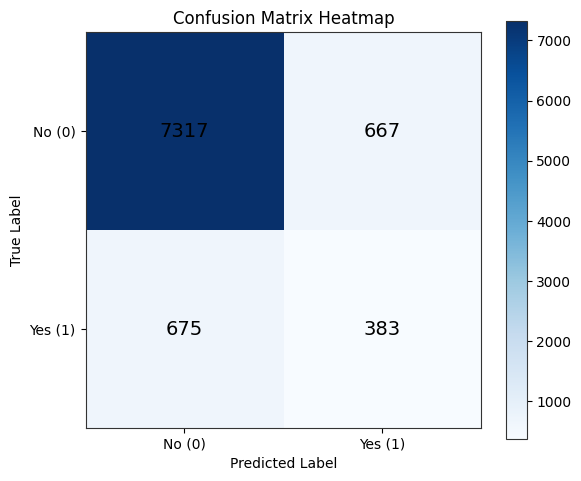

In [308]:
mlp.set_model_parameters(output_threshold=exact_threshold)
mlp.plot_confusion_matrix()

In [309]:
mlp.get_report()

--- Performance Report (Threshold: 0.23) ---
 +- Accuracy:  0.8516
 +- Precision: 0.3648
 +- Recall:    0.3620 
 +- F1-Score:  0.3634 


{'acc': np.float64(0.851581508515815),
 'prec': np.float64(0.3647619047619048),
 'rec': np.float64(0.3620037807183365),
 'f1': np.float64(0.3633776091081594)}

# Genetic Algorithm MLP

## Modified MLP Class
The following a new version of the Class designed to work with a genetic algorithm to optimise weights and biases.

The backpropagation functions have been removed and replaced with a fitness function.

**calculate_fitness**<br>
Returns the specified metric from the get_report function.

**get_weights_as_vector**<br>
Flattens the weights and biases into a long 1 dimensional vector.

**set_weights_from_vector**<br>
Takes a 1D array and puts the pieces back into the correct matrix shapes.<br>
Uses the known sizes of each weight and bias matrix to slice the vector correctly.  

The rest of the functions needed run in a loop outside of the class and are described below.

In [ ]:
class MLP_with_GA:

    # Constructor
    def __init__(self, dataset, **kwargs):

        # Handle Arguments

        self.dataset = dataset

        _random_seed = kwargs.get('random_seed', 67)
        self.debug = kwargs.get('debug', False)

        _test_train_split = kwargs.get('test_train_split', 0.8)    # Default to 80% of the supplied data
        _validation_split = kwargs.get('validation_split', 0.2)    # Default to 20% of the training data

        # Split off training, test and validationdatasets

        df_train, df_test = self._split_stratified (data_set=self.dataset, fraction=_test_train_split, random_state=_random_seed)
        df_train, df_val = self._split_stratified (data_set=df_train, fraction=1-_validation_split, random_state=_random_seed)

        # Split inot X and y for each dataset
        X_train, y_train = self._x_and_y_split(df_train)
        X_test, y_test = self._x_and_y_split(df_test)
        val_X, val_y = self._x_and_y_split(df_val)

        # Convert provided data to numpy arrays
        self.X_np_train = X_train.to_numpy()
        self.y_np_train = y_train.to_numpy().reshape(-1,1)

        self.X_np_val = val_X.to_numpy()
        self.y_np_val = val_y.to_numpy().reshape(-1,1)

        self.X_np_test = X_test.to_numpy()
        self.y_np_test = y_test.to_numpy().reshape(-1,1)

        # Additional Model Parameters
        _act_func = kwargs.get('act_func', 'relu')                      # Hidden layer only, defaults to relu
        _no_hidden_neurons = kwargs.get('no_hidden_neurons', 10)        # Defaults to 10 hidden neurons, per assessment specification
        _no_output_neurons = kwargs.get('no_output_neurons', 1)
        self.output_threshold = kwargs.get('output_threshold', 0.5)

        # Define Model Parameters
        self.no_input_neurons  = self.X_np_train.shape[1]               # Set dynamically based on the input dataset
        self.no_hidden_neurons = _no_hidden_neurons          
        self.no_output_neurons = _no_output_neurons
    
        self.act_func = _act_func

        self.weights_0 = np.random.randn(self.no_input_neurons, self.no_hidden_neurons) 
        self.weights_1 = np.random.randn(self.no_hidden_neurons, self.no_output_neurons)

        self.biases_1 = np.zeros((1, self.no_hidden_neurons))
        self.biases_2 = np.zeros((1, self.no_output_neurons))


    #
    # ***** Data Handling Functions
    # 
    
    def _split_stratified (self, data_set, fraction=0.8, random_state=67):

        # Separate yes and no into two dataframes
        df_yes = data_set[data_set['y'] == 1]
        df_no = data_set[data_set['y'] == 0]

        # Sample 80% from each to maintain the 11.7% ratio
        df_train_yes = df_yes.sample(frac=fraction, random_state=random_state)
        df_train_no = df_no.sample(frac=fraction, random_state=random_state)

        # Combine and Shuffle to prevent date order being learned by the MLP
        df_train = pd.concat([df_train_yes, df_train_no]).sample(frac=1, random_state=random_state)
        df_test = data_set.drop(df_train.index).sample(frac=1, random_state=random_state)

        return df_train, df_test
    
    def _x_and_y_split (self, df):
        # Split datasets into X (features) and y (labels)
        df_X = df.drop(columns='y')
        df_y = df['y']
        return df_X, df_y


    #
    # ***** Activation Functions 
    #

    def _relu(self, x):
        return np.maximum(0, x)

    def _relu_derivative(self, x):
        return (x > 0).astype(float)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _sigmoid_derivative(self, x):
        return x * (1 - x)


    #
    # ***** MLP Process Functions 
    #

    # Simplified to only use relu activation for hidden layer and sigmoid for output layer.
    def _feed_forward(self, X):
        sum_synapse_0 = np.dot(X, self.weights_0) + self.biases_1
        hidden_layer = self._relu(sum_synapse_0)
        
        sum_synapse_1 = np.dot(hidden_layer, self.weights_1) + self.biases_2
        output_layer = self._sigmoid(sum_synapse_1)
        
        # Return everything
        return X, hidden_layer, output_layer

    # Run the feed forward process and return the predicted classes (0 or 1) based on the output threshold
    def _get_predictions(self, X):
        _, _, output = self._feed_forward(X)
        return (output > self.output_threshold).astype(int)
    

    def _get_confusion_matrix(self, X_data=None, y_data=None):
            
        # Default to the test set if no specific data is provided
        if X_data is None:
            X_data = self.X_np_test
            y_data = self.y_np_test

        y_pred = self._get_predictions(X_data)
        
        # Flatten the arrays to ensure they are 1D to compare
        y_true = y_data.flatten()
        y_pred = y_pred.flatten()
        
        # Calculate True Positives, True Negatives, False Positives, and False Negatives
        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        accuracy = (tp + tn) / len(y_true)
        
        return np.array([[tn, fp], [fn, tp]]), accuracy

    #
    # ***** Public Functions 
    #

    # Allows updating of model parameters (e.g. learning rate, output threshold) without needing to retrain the model from scratch
    def set_model_parameters(self, **kwargs):
        self.learning_rate = kwargs.get('learning_rate', self.learning_rate)
        self.output_threshold = kwargs.get('output_threshold', self.output_threshold)

                    
    # Evaluate the model on the provided dataset and return accuracy
    # Allows specifying a custom output threshold for prediction
    # Allows proving a custom dataset instead of the default test set
    def evaluate(self, X_data=None, y_data=None):
            
        # Default to the test set if no specific data is provided
        if X_data is None:
            X_data = self.X_np_test
            y_data = self.y_np_test
        
        self.accuracy = self._calculate_accuracy(X_data, y_data)
        return self.accuracy 
    

    def plot_confusion_matrix(self, save_suffix=''):

        matrix, accuracy = self._get_confusion_matrix()
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(matrix, cmap='Blues')

        # Add colorbar
        plt.colorbar(im)

        # Set labels
        classes = ['No (0)', 'Yes (1)']
        ax.set_xticks(np.arange(len(classes)))
        ax.set_yticks(np.arange(len(classes)))
        ax.set_xticklabels(classes)
        ax.set_yticklabels(classes)

        # Rotate the tick labels and set their alignment.
        plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

        # Loop over data dimensions and create text annotations.
        for i in range(2):
            for j in range(2):
                text = ax.text(j, i, matrix[i, j],
                            ha="center", va="center", color="black", fontsize=14)

        ax.set_title("Confusion Matrix Heatmap")
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        plt.tight_layout()
        plt.savefig(f'graphs/2-mlp_from_scratch/ga_mlp_confusion_matrix_{now_date_timestamp}_threshold_{self.output_threshold}_{save_suffix}.png')
        plt.show()


    # Text Representation
    def print_confusion_matrix(self):
        matrix, self.accuracy = self._get_confusion_matrix() 
        print(f"{'':>15} | {'Predicted No':>12} | {'Predicted Yes':>12} |")
        print("-" * 48)
        print(f"{'Actual No':>15} | {matrix[0][0]:>12} | {matrix[0][1]:>12} |")
        print(f"{'Actual Yes':>15} | {matrix[1][0]:>12} | {matrix[1][1]:>12} |")
        print("-" * 48)
        print (f"Accuracy: {self.accuracy*100:.2f}%")


    # Export the model weights and biases to a JSON file
    def save_weights(self, filename):
        weights_data = {
            'weights_0': self.weights_0.tolist(),
            'weights_1': self.weights_1.tolist(),
            'biases_1': self.biases_1.tolist(),
            'biases_2': self.biases_2.tolist()
        }
        with open(filename, 'w') as f:
            json.dump(weights_data, f, indent=4)

    # Load the model weights and biases from a JSON file
    def load_weights(self, filename):
        with open(filename, 'r') as f:
            weights_data = json.load(f)
            self.weights_0 = np.array(weights_data['weights_0'])
            self.weights_1 = np.array(weights_data['weights_1'])
            self.biases_1 = np.array(weights_data['biases_1'])
            self.biases_2 = np.array(weights_data['biases_2'])

    def get_report(self, X_data, y_data):
        # Get the confusion matrix components
        matrix, accuracy = self._get_confusion_matrix(X_data, y_data)
        tn, fp = matrix[0]
        fn, tp = matrix[1]

        # Calculate metrics
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        return {"acc": accuracy, "prec": precision, "rec": recall, "f1": f1}
    
    # 
    # ***** Genetic Algorithm Functions
    #

    # Flattens all weights and biases into a 1D array (the Chromosome)
    def get_weights_as_vector(self):
    
        _vector = np.concatenate([
            self.weights_0.flatten(), 
            self.weights_1.flatten(), 
            self.biases_1.flatten(), 
            self.biases_2.flatten()
        ])

        return _vector
    
    # Takes a 1D array and puts the pieces back into the correct matrix shapes
    # Uses the known sizes of each weight and bias matrix to slice the vector correctly
    def set_weights_from_vector(self, vector):
        
        start = 0

        # Weights 0
        end = start + self.weights_0.size
        self.weights_0 = vector[start:end].reshape(self.weights_0.shape)

        # Weights 1
        start = end
        end = start + self.weights_1.size
        self.weights_1 = vector[start:end].reshape(self.weights_1.shape)

        # Bias 1
        start = end
        end = start + self.biases_1.size
        self.biases_1 = vector[start:end].reshape(self.biases_1.shape)

        # Bias 2
        start = end
        self.biases_2 = vector[end:].reshape(self.biases_2.shape)


    # Fitness function for the GA
    # This is what the GA will try to maximise by evolving the weights and biases
    # Defaults to using recall
    def calculate_fitness(self, metric='rec'):

        # Use the report function to get teh required metric 
        report = self.get_report(self.X_np_train, self.y_np_train)

        return report[metric]
        

## Genetic Algorithm Functions
Define genetic algorithm operation functions outside of the Class.

**Cross Over**

This takes two parent chromosomes (1D arrays of weights and biases) and creates two child chromosomes by swapping the tails after a random swap point.<br>
This allows the child to inherit some characteristics from each parent.<br>
It proibably will chop a weight matrix in half, but that will be fine as the set_weights_from_vector function (in the new child instance) will put the pieces back together in the correct shapes.<br>

**Mutate**

Run through rthe chromosome and randomly mutate some weights based on the mutation rate.

*mutation_max* is the maximum amount that a weight can be nudged in either direction during mutation.<br>
*mutation_rate* is the probability that any given weight will be mutated.<br>

These are hyperparameters that can be tuned when the function is called.

In [311]:
# This takes two parent chromosomes (1D arrays of weights and biases) and creates two child chromosomes by swapping the tails after a random swap point.
def crossover(parent_chromosome_1, parent_chromosome_2):

    # Single-point crossover: pick a random spot and swap the tails
    swap_point = np.random.randint(len(parent_chromosome_1))
    child_chromosome_1 = np.concatenate([parent_chromosome_1[:swap_point], parent_chromosome_2[swap_point:]])
    child_chromosome_2 = np.concatenate([parent_chromosome_2[:swap_point], parent_chromosome_1[swap_point:]])
    return child_chromosome_1, child_chromosome_2

# Run through rhe chromosome and randomly mutate some weights based on the mutation rate
def mutate(chromosome, mutation_rate=0.01, mutation_max=0.2):

    mutations_count = 0
    for i in range(len(chromosome)):

        # Roll a random number and compare to mutation rate
        # np.random.rand() generates a random float between 0 and 1
        if np.random.rand() < mutation_rate:
            # Mutation: adjust by a small +ve or -ve random value
            chromosome[i] += np.random.normal(-mutation_max, mutation_max)
            mutations_count += 1
        else:
            # Do nothing, shown to make it clear that the weight is unchanged
            chromosome[i] += 0  
    return chromosome, mutations_count

**Run Evolution**

This is the main loop of the genetic algorithm,

The following steps are followed:

- Create an initial population. The population size is a parameter.
- Loop through the generations. For each generation:

1) Calculate the fitness matric for each individual.
2) Sort the individuals based on fitness (in descending order, highest at the top).
3) Keep the very best individuals each time. This is eliteism in action, and can be controlled by the elite_size variable.
3) Cull the bottom half of the population. The culling_rate variable is used to remove the bottom percentage of the population with each generation. This is set to 50% by default, leaving the top 50% of parents available to create the next generation.
4) Generate new children to fill the population using crossover and possible mutation.


The metric used to calculate the fitness of an individual MLP can be based on **maximising** any of these metrics:
```
    metrics = {
        'acc': 'Accuracy',
        'prec': 'Precision',
        'rec': 'Recall',
        'f1': 'F1-Score'
    }
```

References: Eliteism from https://en.wikipedia.org/wiki/Genetic_algorithm

In [312]:
def run_evolution(dataset, pop_size=50, generations=20, metric='rec', culling_rate=0.5, elite_size = 10, mutation_rate=0.01):
    
    metrics = {
        'acc': 'Accuracy',
        'prec': 'Precision',
        'rec': 'Recall',
        'f1': 'F1-Score'
    }

    keep_rate = 1 - culling_rate

    # Check supplied metric is valid, otherwise default to recall
    if metric not in metrics:
        print_output("Invalid Metric", f"Metric '{metric}' not recognised. Defaulting to Recall.", colour='red')
        metric = 'rec'

    # Check whether the elite size is valid given the population size and culling rate, and adjust if necessary to prevent errors during selection
    if elite_size >= pop_size: 
        print_output("Invalid Elite Size", f"Elite size of {elite_size} is too large for population size of {pop_size}. Reducing elite size to {pop_size - 1}.", colour='red')
        elite_size = pop_size - 1

    if elite_size >= (pop_size * keep_rate):
        print_output("Invalid Elite Size", f"Elite size of {elite_size} is too large for culling rate of {culling_rate}. Reducing elite size to {int(pop_size * keep_rate) - 1}.", colour='red')
        elite_size = int(pop_size * keep_rate) - 1

    # Initialize an empty list to hold the population of MLP objects
    population = []

    # To store total mutations per generation - for plotting a pretty graph
    mutation_history = [] 
    # To store best fitness per generation 
    fitness_history = []  

    # Loop to create each individual member of the population
    for i in range(pop_size):
        # Instantiate a new MLP model, feeding in the dataset and any required parameters
        # The GA version randmises the weights and biases in the constructor, so no need to train.
        individual = MLP_with_GA(dataset, debug = False)
    
        # Add the newly created model to the population list
        population.append(individual)

    print_output("Population", f"{len(population)} individuals.", colour='yellow')

    def calculate_population_fitness(population, metric):
        # Create an empty list to store the fitness results for the current generation
        fitness_scores = []

        # Iterate through every individual in the population
        for individual in population:

            # Calculate how well this specific network performed
            score = individual.calculate_fitness(metric=metric)
            
            # Store the score in our list
            fitness_scores.append(score)

        # Sort the population based on fitness scores, keeping the individuals and their scores together
        combined_list = []
        for i in range(len(population)):
            pair = (fitness_scores[i], population[i])
            combined_list.append(pair)

        # Sort the combined list by fitness score in descending order
        combined_list.sort(key=lambda x: x[0], reverse=True)
        return combined_list
    
    def sort_population_by_fitness(population, metric):

        combined_list = calculate_population_fitness(population, metric)

        # Create a new sorted population list based on the sorted combined list
        pop_sorted = []
        for score, mlp in combined_list:
            pop_sorted.append(mlp)
        return pop_sorted, combined_list

    # Main Evolution Loop
    for gen in range(generations):

        # Evaluate Fitness
    
        #combined_list = calculate_population_fitness(population, metric)
        pop_sorted, combined_list = sort_population_by_fitness(population, metric)

        best_fitness_score = combined_list[0][0]
        fitness_history.append(best_fitness_score)

        # Print the best fitness score of this generation, along with the metric being used
        print_output("Generation", f"{gen}", newline=False, colour='cyan')
        print_output(f"Metric is {metrics.get(metric, metric)}", f"{best_fitness_score:.4f}", colour='green')

        # Selection (Default: keep the top 50% as parents)
        # The keep_rate variable determines what percentage of the population is discarded each generation.
        num_parents = int(pop_size * keep_rate)
        parents = pop_sorted[:num_parents]
        
        # 4. Create Next Generation
        next_gen = []

        # Elitism: Keep the best ones
        next_gen.extend(parents[:elite_size]) 
        
        total_gen_mutations = 0
        # Crossover and Mutation are used to fill the rest of the next generation
        while len(next_gen) < pop_size:

            # Pick two random parents
            parent_1, parent_2 = np.random.choice(parents, 2, replace=False)
            
            # Crossover
            child_1_chromosome, child_2_chromosome = crossover(parent_1.get_weights_as_vector(), parent_2.get_weights_as_vector())
            
            # Mutate
            child_1_chromosome, child_1_mut_count = mutate(child_1_chromosome, mutation_rate=mutation_rate, mutation_max=0.1)
            child_2_chromosome, child_2_mut_count = mutate(child_2_chromosome, mutation_rate=mutation_rate, mutation_max=0.1)

            total_gen_mutations += (child_1_mut_count + child_2_mut_count)
            
            # Create new MLP instances for children
            child_1 = MLP_with_GA(dataset)
            child_1.set_weights_from_vector(child_1_chromosome)
            child_2 = MLP_with_GA(dataset)
            child_2.set_weights_from_vector(child_2_chromosome)
            
            # Add them to the generation
            next_gen.extend([child_1, child_2])

        # Set the current population to the next generation
        # If population size is an odd number, there may be an extra child, so trim the next generation list to the correct population size
        population = next_gen[:pop_size]

        mutation_history.append(total_gen_mutations)

    # On completion, return the fittest model from the final generation 
    pop_sorted, combined_list = sort_population_by_fitness(population, metric)
    best_fitness_score = combined_list[0][0]
    print_output(f"\nFinal best fitness score", f"{best_fitness_score:.4f}", colour='cyan')

    return population[0], fitness_history, mutation_history

In [313]:
def plot_evolutionary_progress(fitness_history, mutation_history, save_suffix=''):

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot fitness on the first axis
    ax1.set_xlabel('Generation')
    ax1.set_ylabel('Best Fitness Score', color=palette[0], fontweight='bold')
    ax1.plot(fitness_history, color=palette[0], linewidth=3, label='Best Fitness')
    ax1.tick_params(axis='y', labelcolor=palette[0])

    # Create a second axis for mutations
    ax2 = ax1.twinx()
    ax2.set_ylabel('Total Mutations', color=palette[1], fontweight='bold')
    ax2.bar(range(len(mutation_history)), mutation_history, alpha=0.3, color=palette[1], label='Mutation Volume')
    ax2.tick_params(axis='y', labelcolor=palette[1])

    plt.title(f'Genetic Algorithm: Fitness Improvement vs. Mutation Volatility', fontsize=14)
    fig.tight_layout()
    plt.savefig(f'graphs/2-mlp_from_scratch/ga_mlp_fitness_mutation_history_{now_date_timestamp}_{save_suffix}.png')
    plt.show()

The default fitness function is to use the recall value:

In [314]:
best_mlp, fitness_history, mutation_history = run_evolution(df, pop_size=20, generations=20, metric='rec', culling_rate=0.5, elite_size=5, mutation_rate = 0.05)

Population: 20 individuals.
Generation: 0 Metric is Recall: 0.9814
Generation: 1 Metric is Recall: 0.9968
Generation: 2 Metric is Recall: 0.9968
Generation: 3 Metric is Recall: 0.9968
Generation: 4 Metric is Recall: 0.9968
Generation: 5 Metric is Recall: 0.9968
Generation: 6 Metric is Recall: 0.9973
Generation: 7 Metric is Recall: 0.9973
Generation: 8 Metric is Recall: 0.9973
Generation: 9 Metric is Recall: 0.9973
Generation: 10 Metric is Recall: 0.9997
Generation: 11 Metric is Recall: 0.9997
Generation: 12 Metric is Recall: 1.0000
Generation: 13 Metric is Recall: 1.0000
Generation: 14 Metric is Recall: 1.0000
Generation: 15 Metric is Recall: 1.0000
Generation: 16 Metric is Recall: 1.0000
Generation: 17 Metric is Recall: 1.0000
Generation: 18 Metric is Recall: 1.0000
Generation: 19 Metric is Recall: 1.0000

Final best fitness score: 1.0000


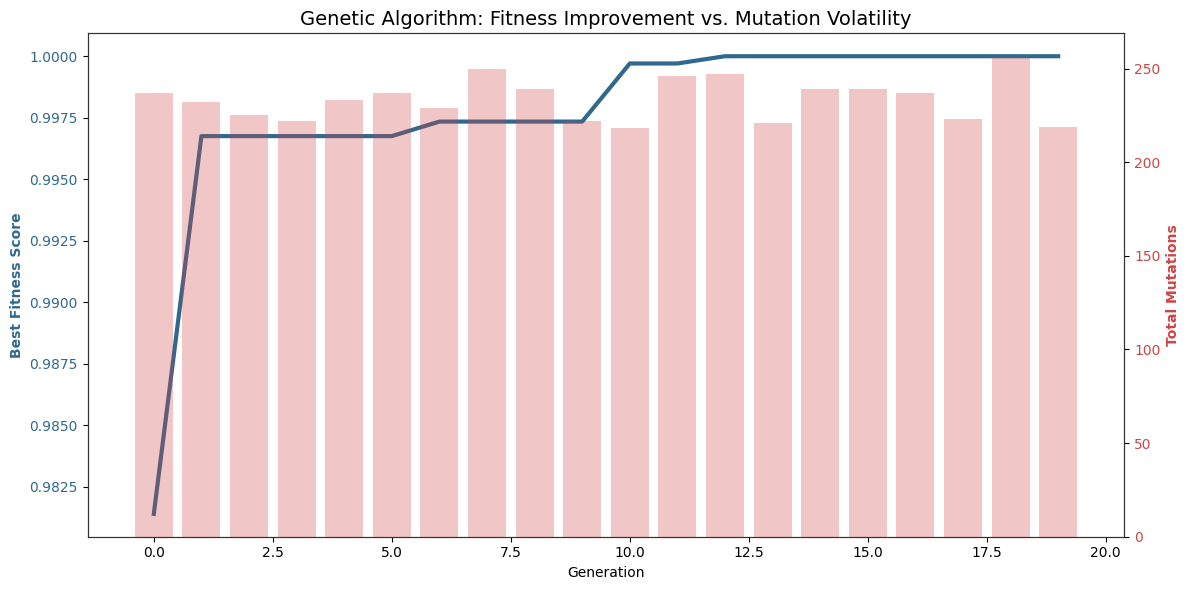

In [315]:
plot_evolutionary_progress(fitness_history, mutation_history, save_suffix='rec-20g-20pop-5elite-05mut')

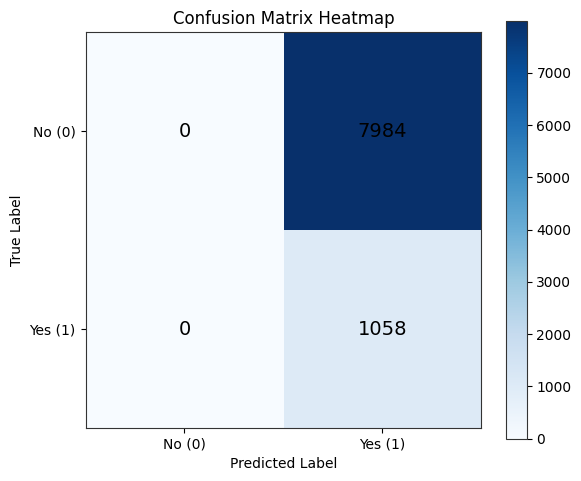

In [316]:
best_mlp.plot_confusion_matrix(save_suffix='rec-20g-20pop-5elite-05mut')

In [317]:
best_mlp.print_confusion_matrix()

                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |            0 |         7984 |
     Actual Yes |            0 |         1058 |
------------------------------------------------
Accuracy: 11.70%


In [318]:
best_mlp.get_report(best_mlp.X_np_test, best_mlp.y_np_test)

{'acc': np.float64(0.11700951117009512),
 'prec': np.float64(0.11700951117009512),
 'rec': np.float64(1.0),
 'f1': np.float64(0.20950495049504952)}

(I have recorded the confusion matrix here because the genetic algorithm is random and if run again will generat eslightly differnet scores.)

```
                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |           98 |         7886 |
     Actual Yes |            4 |         1054 |
------------------------------------------------
Accuracy: 12.74%
```

This is really bad!<br>
However, this is the best score for recall that the MLP has generated! (99%).<br>
Because the fitness function told the GA to maximize recall, it learned that the way to never miss a 'yes' is to predict it for everyone!

A better metric to use would be the F1-Score because this is made up of both recall and precision.<br>
Running the same parameters, but specifying the F1-Score metric as the fitness function:


In [319]:
best_mlp, fitness_history, mutation_history = run_evolution(df, pop_size=20, generations=20, metric='f1', culling_rate=0.5, elite_size=5, mutation_rate = 0.05)

Population: 20 individuals.
Generation: 0 Metric is F1-Score: 0.2372
Generation: 1 Metric is F1-Score: 0.2372
Generation: 2 Metric is F1-Score: 0.2556
Generation: 3 Metric is F1-Score: 0.2575
Generation: 4 Metric is F1-Score: 0.2575
Generation: 5 Metric is F1-Score: 0.2590
Generation: 6 Metric is F1-Score: 0.2643
Generation: 7 Metric is F1-Score: 0.2643
Generation: 8 Metric is F1-Score: 0.2678
Generation: 9 Metric is F1-Score: 0.2710
Generation: 10 Metric is F1-Score: 0.2710
Generation: 11 Metric is F1-Score: 0.2746
Generation: 12 Metric is F1-Score: 0.2768
Generation: 13 Metric is F1-Score: 0.2768
Generation: 14 Metric is F1-Score: 0.2787
Generation: 15 Metric is F1-Score: 0.2852
Generation: 16 Metric is F1-Score: 0.2861
Generation: 17 Metric is F1-Score: 0.2873
Generation: 18 Metric is F1-Score: 0.2876
Generation: 19 Metric is F1-Score: 0.2885

Final best fitness score: 0.2913


Create a plot of the best fitness and number of mutations.

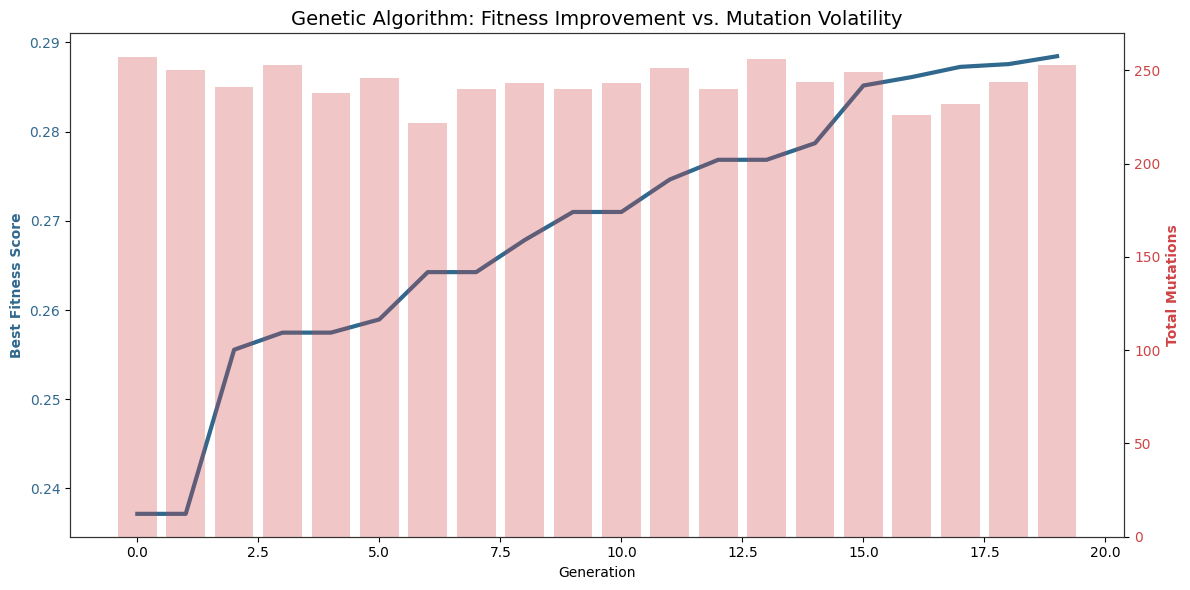

In [320]:
plot_evolutionary_progress(fitness_history, mutation_history, save_suffix='f1-20g-20pop-5elite-05mut')



Using the 'best mlp' from a fitness pespective, the confusion matrix looks like this:

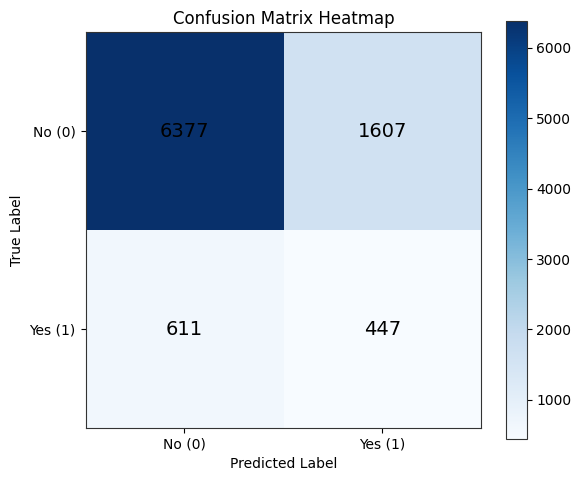

In [321]:
best_mlp.plot_confusion_matrix(save_suffix='f1-20g-20pop-5elite-05mut')

In [322]:
best_mlp.print_confusion_matrix()

                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |         6377 |         1607 |
     Actual Yes |          611 |          447 |
------------------------------------------------
Accuracy: 75.47%


And the metric report is as follows:

In [323]:
best_mlp.get_report(best_mlp.X_np_test, best_mlp.y_np_test)

{'acc': np.float64(0.7547002875470029),
 'prec': np.float64(0.21762414800389485),
 'rec': np.float64(0.4224952741020794),
 'f1': np.float64(0.28727506426735216)}

On one run, I got the following confusion matrix:

```
                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |         6405 |         1579 |
     Actual Yes |          550 |          508 |
------------------------------------------------
Accuracy: 76.45%

```
True Positives: This shows the GA is successfully learning the profile of a subscriber. This is a better value than the original 'from scratch' MLP produced, although accuracy has been reduced.

False Negatives: The model is doing ok; this is a lower value than before too.

False Positive: The GA generated model has more False Positives but the cost of an extra call is negligible compared to the value of a secured term deposit.

I am going to use many more generations to see whether this can be improved. All the other factors remain the same.

In [324]:
best_mlp, fitness_history, mutation_history = run_evolution(df, pop_size=20, generations=200, metric='f1', culling_rate=0.5, elite_size=5, mutation_rate = 0.05)

Population: 20 individuals.
Generation: 0 Metric is F1-Score: 0.2388
Generation: 1 Metric is F1-Score: 0.2506
Generation: 2 Metric is F1-Score: 0.2506
Generation: 3 Metric is F1-Score: 0.2610
Generation: 4 Metric is F1-Score: 0.2623
Generation: 5 Metric is F1-Score: 0.2640
Generation: 6 Metric is F1-Score: 0.2640
Generation: 7 Metric is F1-Score: 0.2643
Generation: 8 Metric is F1-Score: 0.2671
Generation: 9 Metric is F1-Score: 0.2685
Generation: 10 Metric is F1-Score: 0.2717
Generation: 11 Metric is F1-Score: 0.2727
Generation: 12 Metric is F1-Score: 0.2746
Generation: 13 Metric is F1-Score: 0.2763
Generation: 14 Metric is F1-Score: 0.2816
Generation: 15 Metric is F1-Score: 0.2816
Generation: 16 Metric is F1-Score: 0.2826
Generation: 17 Metric is F1-Score: 0.2829
Generation: 18 Metric is F1-Score: 0.2847
Generation: 19 Metric is F1-Score: 0.2887
Generation: 20 Metric is F1-Score: 0.2887
Generation: 21 Metric is F1-Score: 0.2887
Generation: 22 Metric is F1-Score: 0.2893
Generation: 23 M

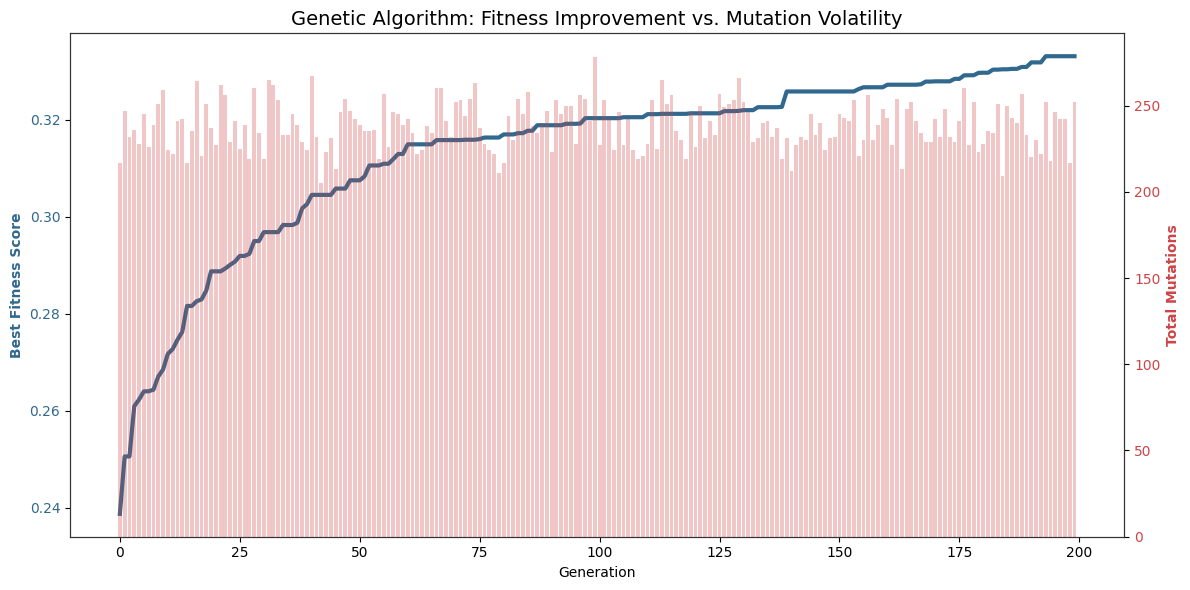

In [325]:
plot_evolutionary_progress(fitness_history, mutation_history, save_suffix='f1-200g-20pop-5elite-05mut')

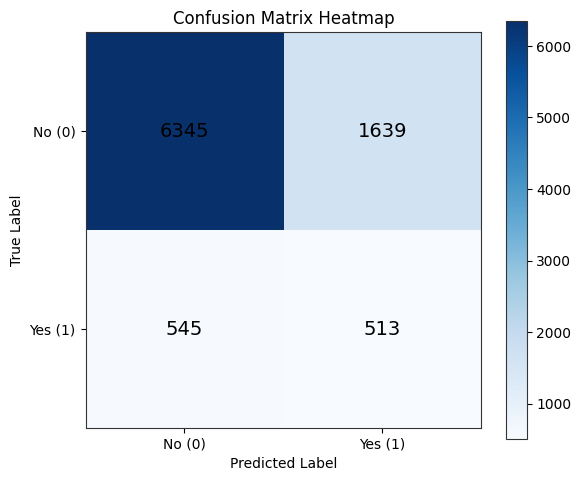

In [326]:
best_mlp.plot_confusion_matrix(save_suffix='f1-200g-20pop-5elite-05mut')

In [327]:
best_mlp.print_confusion_matrix()

                | Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |         6345 |         1639 |
     Actual Yes |          545 |          513 |
------------------------------------------------
Accuracy: 75.85%


In [328]:
best_mlp.get_report(best_mlp.X_np_test, best_mlp.y_np_test)

{'acc': np.float64(0.7584605175846052),
 'prec': np.float64(0.2383828996282528),
 'rec': np.float64(0.4848771266540643),
 'f1': np.float64(0.31962616822429907)}

```
| Predicted No | Predicted Yes |
------------------------------------------------
      Actual No |         6345 |         1639 |
     Actual Yes |          545 |          513 |
------------------------------------------------
Accuracy: 75.85%
```

This is the result from one run. It's not much better than the 20 generation model!<br>

---
**End of Notebook**

---